# Installs

In [1]:
# !pip install shap
# !pip install grad-cam
# !pip install tqdm
# !pip install ultralytics opencv-python nibabel kagglehub
# !pip install ultralytics nibabel opencv-python matplotlib numpy pandas pillow scikit-learn

# Imports

In [21]:
import numpy as np
print(np.__version__)
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import kagglehub
import nibabel as nib
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

1.26.4


# Dataset - Brats 2020

In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "awsaf49/brats20-dataset-training-validation"
)

print("Dataset path:", path)

Dataset path: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1


In [4]:
os.listdir(path)

['BraTS2020_TrainingData', 'BraTS2020_ValidationData']

In [5]:
base_path = os.path.join(
    path,
    "BraTS2020_TrainingData",
    "MICCAI_BraTS2020_TrainingData"
)

cases = []

for folder in os.listdir(base_path):

    full_path = os.path.join(base_path, folder)

    if os.path.isdir(full_path):
        cases.append(full_path)

print("Total cases:", len(cases))
print(cases[:3])

Total cases: 369
['C:\\Users\\conno\\.cache\\kagglehub\\datasets\\awsaf49\\brats20-dataset-training-validation\\versions\\1\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_001', 'C:\\Users\\conno\\.cache\\kagglehub\\datasets\\awsaf49\\brats20-dataset-training-validation\\versions\\1\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_002', 'C:\\Users\\conno\\.cache\\kagglehub\\datasets\\awsaf49\\brats20-dataset-training-validation\\versions\\1\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_003']


In [6]:
# Loads one MRI scan

sample_case = cases[0]

files = os.listdir(sample_case)
print(files)

['BraTS20_Training_001_flair.nii', 'BraTS20_Training_001_seg.nii', 'BraTS20_Training_001_t1.nii', 'BraTS20_Training_001_t1ce.nii', 'BraTS20_Training_001_t2.nii']


In [7]:
# Loading MRI and Mask

flair_path = None
mask_path = None

for file in files:

    if "flair" in file.lower():
        flair_path = os.path.join(sample_case, file)

    if "seg" in file.lower():
        mask_path = os.path.join(sample_case, file)

print("FLAIR:", flair_path)
print("MASK:", mask_path)

FLAIR: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001\BraTS20_Training_001_flair.nii
MASK: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001\BraTS20_Training_001_seg.nii


In [8]:
# getting structure of data

print(path)

for root, dirs, files in os.walk(path):
    print(root)
    print(files[:5])
    print("-" * 50)

    # stoppinh after a few folders
    if "BraTS20_Training_001" in root:
        break

C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1
[]
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData
[]
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData
['name_mapping.csv', 'survival_info.csv']
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001
['BraTS20_Training_001_flair.nii', 'BraTS20_Training_001_seg.nii', 'BraTS20_Training_001_t1.nii', 'BraTS20_Training_001_t1ce.nii', 'BraTS20_Training_001_t2.nii']
-------

In [9]:
# CELL 9 FIND MRI + MASK FILES

patient_folder = None

for folder in os.listdir(path):
    full_path = os.path.join(path, folder)

    if os.path.isdir(full_path):
        patient_folder = full_path
        break

print("Patient folder:", patient_folder)

files = os.listdir(patient_folder)

flair_path = None
mask_path = None

for file in files:

    if "flair" in file.lower():
        flair_path = os.path.join(patient_folder, file)

    if "seg" in file.lower():
        mask_path = os.path.join(patient_folder, file)

print("FLAIR:", flair_path)
print("MASK:", mask_path)

Patient folder: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData
FLAIR: None
MASK: None


In [10]:
base_path = os.path.join(path, "BraTS2020_TrainingData")
print(base_path)
print(os.listdir(base_path)[:5])

C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData
['MICCAI_BraTS2020_TrainingData']


In [11]:
# Getting MRI shape and Mask shape

base_path = os.path.join(path, "BraTS2020_TrainingData", "MICCAI_BraTS2020_TrainingData")

patient_folder = next(
    os.path.join(base_path, f)
    for f in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, f))
)

files = os.listdir(patient_folder)

flair_path = next(os.path.join(patient_folder, f) for f in files if "flair" in f.lower())
mask_path  = next(os.path.join(patient_folder, f) for f in files if "seg" in f.lower())

flair = nib.load(flair_path).get_fdata()
mask = nib.load(mask_path).get_fdata()

print("MRI shape:", flair.shape)
print("Mask shape:", mask.shape)

MRI shape: (240, 240, 155)
Mask shape: (240, 240, 155)


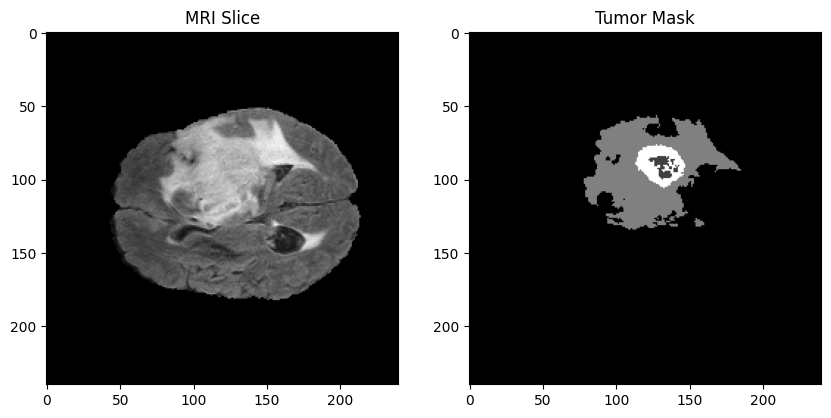

In [12]:
# Show MRI slice and tumor mask
slice_index = 75

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(flair[:,:,slice_index], cmap='gray')
plt.title("MRI Slice")

plt.subplot(1,2,2)
plt.imshow(mask[:,:,slice_index], cmap='gray')
plt.title("Tumor Mask")

plt.show()

In [13]:
# CREATE OUTPUT FOLDERS

BASE_DIR = "brain_tumor_dataset"

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

print("Folders created.")

Folders created.


In [14]:
# Convert MASK to POLYGON ( for Yolo v8 segmentation model to work)
import cv2
import numpy as np

def mask_to_polygon(mask_slice):

    mask = (mask_slice > 0).astype(np.uint8) * 255

    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    largest = max(contours, key=cv2.contourArea)

    if cv2.contourArea(largest) < 20:   # slightly stricter
        return None

    return largest.reshape(-1, 2)

In [15]:
import cv2
import numpy as np

def mask_to_bbox(mask_slice):

    mask = (mask_slice > 0).astype(np.uint8)

    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return None

    x_min = xs.min()
    x_max = xs.max()

    y_min = ys.min()
    y_max = ys.max()

    return x_min, y_min, x_max, y_max

In [16]:
# ============================================================
# CELL 24 — CREATE YOLO DETECTION LABELS
# ============================================================

image_paths = []
counter = 0

for case in tqdm(cases):

    files = os.listdir(case)

    flair_path = None
    mask_path = None

    for file in files:

        if "flair" in file.lower():
            flair_path = os.path.join(case, file)

        if "seg" in file.lower():
            mask_path = os.path.join(case, file)

    if flair_path is None or mask_path is None:
        continue

    flair = nib.load(flair_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    for i in range(35, 115, 8):

        image_slice = flair[:, :, i]
        mask_slice = mask[:, :, i]

        is_tumor = np.max(mask_slice) > 0

        if not is_tumor and np.random.rand() > 0.10:
            continue

        bbox = mask_to_bbox(mask_slice)

        if bbox is None:
            continue

        x_min, y_min, x_max, y_max = bbox

        h, w = image_slice.shape

        x_center = ((x_min + x_max) / 2) / w
        y_center = ((y_min + y_max) / 2) / h

        bbox_width = (x_max - x_min) / w
        bbox_height = (y_max - y_min) / h

        image_slice = cv2.normalize(
            image_slice,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        )

        image_slice = image_slice.astype(np.uint8)

        image_slice = cv2.cvtColor(
            image_slice,
            cv2.COLOR_GRAY2RGB
        )

        filename = f"tumor_{counter}"

        cv2.imwrite(
            f"{BASE_DIR}/images/train/{filename}.jpg",
            image_slice
        )

        with open(
            f"{BASE_DIR}/labels/train/{filename}.txt",
            "w"
        ) as f:

            f.write(
                f"0 {x_center} {y_center} {bbox_width} {bbox_height}"
            )

        image_paths.append(filename)

        counter += 1

print("Total saved images:", counter)

100%|██████████████████████████████████████████████████████| 369/369 [01:24<00:00,  4.34it/s]

Total saved images: 2594


In [17]:
train_files, val_files = train_test_split(
    image_paths,
    test_size=0.2,
    random_state=42
)

In [18]:
# moving the validation set files
import shutil

for file in val_files:

    shutil.copy(
        f"{BASE_DIR}/images/train/{file}.jpg",
        f"{BASE_DIR}/images/val/{file}.jpg"
    )

    shutil.copy(
        f"{BASE_DIR}/labels/train/{file}.txt",
        f"{BASE_DIR}/labels/val/{file}.txt"
    )

print("Validation files copied.")

Validation files copied.


In [19]:
# creating yolo dataset yaml file
yaml_text = f"""
path: {BASE_DIR}

train: images/train
val: images/val

names:
  0: tumor
"""

In [22]:
model = YOLO("yolov8n.pt")

In [23]:
model.train(
    data="dataset.yaml",
    epochs=10,
    imgsz=192,
    batch=8,
    workers=2,
    mosaic=0,
    fliplr=0.1,
    scale=0.1,
    degrees=0,
    patience=3,
    cache=True
)

Ultralytics 8.4.58  Python-3.10.20 torch-2.12.0+cpu CPU (13th Gen Intel Core i7-13700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.1, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=192, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=3, perspective=0.0, plo

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000025110A3FF10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480